# 08 — What can the images predict on their own?

Ground truth comes from the transcriptome (cell-type annotation, niches); inputs are **image features only**
(intensities, distributions, texture, morphology, edge distance; no transcript counts). Gradient-boosted trees,
5-fold cross-validation **grouped by animal** (test animals never seen in training), 18S-segmented cells.

1. Cell type (L1) — overall, per class, confusions.
2. Which stain carries identity — single-channel and morphology-only models, everything-but-18S (18S drew the masks),
   and cell + **image-only neighbourhood** (mean image features of the 15 nearest cells).
3. Subtypes within a type (L2).
4. Anatomy and lesion state from images vs a transcriptome-composition baseline (cell types of the 15 nearest cells).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold

from beyondboundaries import data, plotting

plotting.style()
SRC = "notebooks/08_image_only_prediction.ipynb"
OUT = ROOT / "results" / "08_image_only_prediction"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "data" / "pred08"
CACHE.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
rng = np.random.default_rng(0)

fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].copy()
_f64 = fa.select_dtypes("float64").columns
fa[_f64] = fa[_f64].astype(np.float32)            # halves memory on the shared machine
for ch in CH:
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])
_num = fa.select_dtypes("number").columns
fa[_num] = fa[_num].replace([np.inf, -np.inf], np.nan)   # ratios with ~0 denominators; trees handle NaN

CELL = []
for ch in CH:
    CELL += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    CELL += [f"{ch}_radial_b{k}" for k in range(5)]
    CELL += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    CELL += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
MORPH = [c for c in fa.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset"]
CELL += MORPH + ["edge_um"]

# image-only neighbourhood: mean of a compact image feature set over the 15 nearest cells (same section, self excluded)
NB_BASE = [f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "terr")] + \
          [f"{ch}_glcm_{k}" for ch in CH for k in ("contrast", "correlation")] + \
          ["morph_cell_area_um2", "morph_nuc_cell_ratio", "morph_cell_eccentricity"]
K = 15
nb = np.full((len(fa), len(NB_BASE)), np.nan, np.float32)
vals = fa[NB_BASE].values.astype(np.float32)
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K + 1, len(idx)))
    nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)
NBH = [f"nbhd_{c}" for c in NB_BASE]
fa[NBH] = nb
print(len(CELL), "cell image features;", len(NBH), "neighbourhood image features")


def cv_predict(df, y, feats, key, groups="sample_name", max_per_class=6000, n_folds=5):
    """Grouped-CV predictions (cached). Balanced subsample per class to keep runtime bounded."""
    cache = CACHE / f"{key}.parquet"
    if cache.exists():
        return pd.read_parquet(cache)
    y = pd.Series(y, index=df.index).astype(str)
    keep = np.concatenate([rng.choice(g.index.values, min(len(g), max_per_class), replace=False)
                           for _, g in y.groupby(y)])
    d, yy = df.loc[keep], y.loc[keep]
    X = d[feats].values.astype(np.float32)
    pred = pd.Series(index=d.index, dtype=object)
    classes = np.sort(yy.unique())
    proba = pd.DataFrame(0.0, index=d.index, columns=classes)
    for tr, te in GroupKFold(n_folds).split(X, groups=d[groups].astype(str).values):
        m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, early_stopping=True, random_state=0,
                                           class_weight="balanced").fit(X[tr], yy.values[tr])
        pred.iloc[te] = m.predict(X[te])
        proba.iloc[te, :] = pd.DataFrame(m.predict_proba(X[te]), columns=m.classes_).reindex(columns=classes, fill_value=0).values
    out = pd.concat([pd.DataFrame({"true": yy, "pred": pred.astype(str)}), proba.add_prefix("p_")], axis=1)
    out.to_parquet(cache)
    return out


def scores(r):
    return pd.Series({"balanced acc.": balanced_accuracy_score(r.true, r.pred),
                      "macro F1": f1_score(r.true, r.pred, average="macro"),
                      "chance (balanced)": 1 / r.true.nunique(), "n": len(r)})

/tmp/ipykernel_23452/2269302441.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
/tmp/ipykernel_23452/2269302441.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
/tmp/ipykernel_23452/2269302441.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

/tmp/ipykernel_23452/2269302441.py:55: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


/tmp/ipykernel_23452/2269302441.py:55: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)
/tmp/ipykernel_23452/2269302441.py:55: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


106 cell image features; 23 neighbourhood image features


/tmp/ipykernel_23452/2269302441.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = nb
/tmp/ipykernel_23452/2269302441.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = nb
/tmp/ipykernel_23452/2269302441.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = nb
/tmp/ip

## 1. Cell type (L1) from images only

In [2]:
vc = fa.Anno_L1_curated.value_counts()
TYPES = [t for t in vc.index if vc[t] >= 500 and t not in ("Doublet", "T_B_doublet")]
ct = fa[fa.Anno_L1_curated.isin(TYPES)]
r_all = cv_predict(ct, ct.Anno_L1_curated, CELL + NBH, "L1_cell+nbhd")
r_cell = cv_predict(ct, ct.Anno_L1_curated, CELL, "L1_cell")
pd.DataFrame({"cell features": scores(r_cell), "cell + image neighbourhood": scores(r_all)}).T.round(3)

,balanced acc.,macro F1,chance (balanced),n
cell features,0.444,0.433,0.071,75601.0
cell + image neighbourhood,0.464,0.455,0.071,75601.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L1_confusion.png')

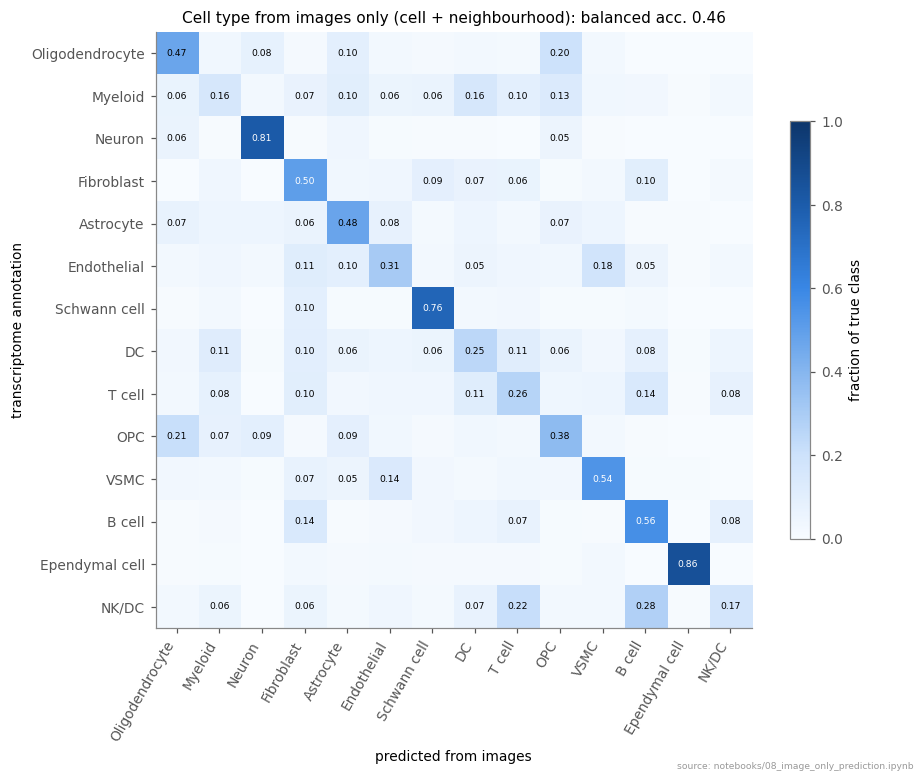

In [3]:
order = [t for t in TYPES]
cm = confusion_matrix(r_all.true, r_all.pred, labels=order, normalize="true")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm, cmap=plotting.SEQ, vmin=0, vmax=1)
for i in range(len(order)):
    for j in range(len(order)):
        if cm[i, j] >= 0.05:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > 0.5 else "black")
ax.set_xticks(range(len(order)), order, rotation=60, ha="right"); ax.set_yticks(range(len(order)), order)
ax.set_xlabel("predicted from images"); ax.set_ylabel("transcriptome annotation")
fig.colorbar(im, ax=ax, label="fraction of true class", shrink=0.7)
ax.set_title(f"Cell type from images only (cell + neighbourhood): balanced acc. {scores(r_all)['balanced acc.']:.2f}")
fig.tight_layout()
plotting.save_fig(fig, "L1_confusion", OUT, SRC)

,cell features,cell + neighbourhood
Myeloid,0.139,0.156
NK/DC,0.174,0.172
DC,0.212,0.247
T cell,0.240,0.265
Endothelial,0.286,0.306
OPC,0.371,0.379
Oligodendrocyte,0.463,0.471
Astrocyte,0.462,0.475
Fibroblast,0.472,0.500
VSMC,0.499,0.543


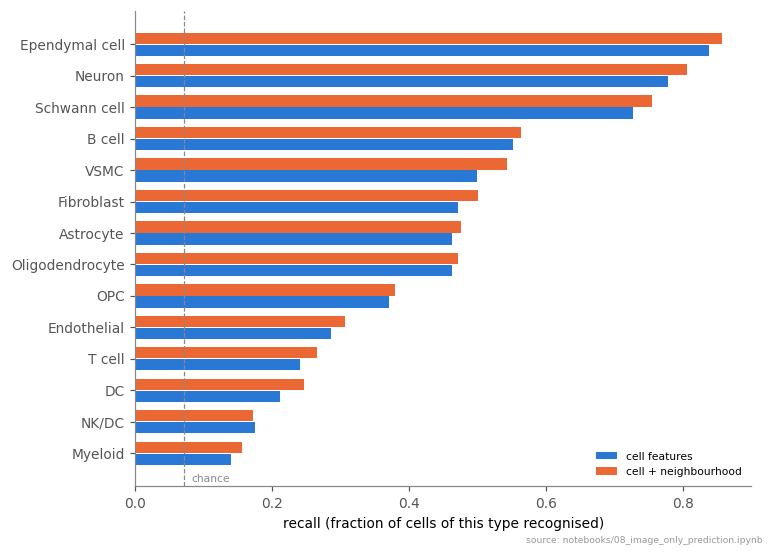

In [4]:
rec = pd.DataFrame({"cell features": pd.Series(np.diag(confusion_matrix(r_cell.true, r_cell.pred, labels=order, normalize="true")), index=order),
                    "cell + neighbourhood": pd.Series(np.diag(cm), index=order)})
rec = rec.sort_values("cell + neighbourhood")
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(rec))
for k, c in enumerate(rec.columns):
    ax.barh(y + (k - 0.5) * 0.38, rec[c], height=0.36, color=plotting.CATEGORICAL[k], label=c)
ax.axvline(1 / len(order), color="#888888", lw=0.8, ls="--")
ax.text(1 / len(order) + 0.01, -0.9, "chance", fontsize=7, color="#888888")
ax.set_yticks(y, rec.index); ax.set_xlabel("recall (fraction of cells of this type recognised)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "L1_recall_per_type", OUT, SRC)
rec.round(3)

## 2. Which stain carries cell identity?
Same task, restricted feature sets (cell features only, no neighbourhood; ≤ 3,000 cells per class for the
restricted sets — the full-feature rows are the 6,000-per-class models from section 1).

,balanced acc.,macro F1,chance (balanced),n
morphology only,0.172,0.162,0.071,41046.0
DAPI only,0.239,0.226,0.071,41046.0
ATP1A1/CD45/E-Cad only,0.211,0.195,0.071,41046.0
18S rRNA only,0.274,0.252,0.071,41046.0
αSMA/Vimentin only,0.254,0.230,0.071,41046.0
"all channels, no morphology",0.399,0.387,0.071,41046.0
all except 18S,0.400,0.391,0.071,41046.0
all image (cell),0.444,0.433,0.071,75601.0
all image + neighbourhood,0.464,0.455,0.071,75601.0


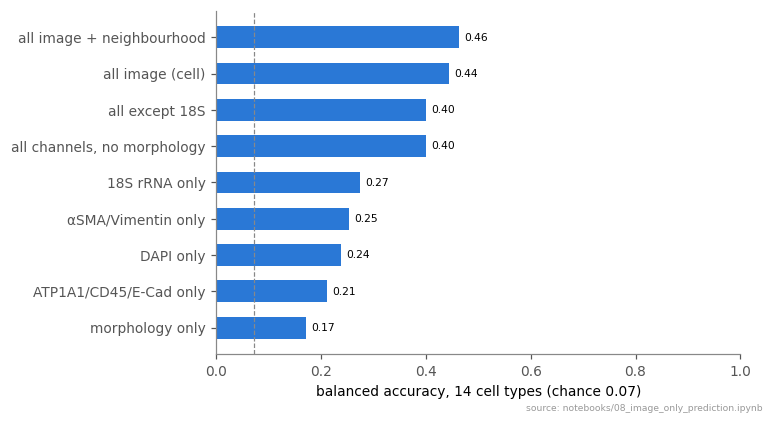

In [5]:
SETS = {"morphology only": MORPH,
        **{f"{plotting.CHANNEL_LABELS[ch]} only": [c for c in CELL if c.startswith(ch + "_")] for ch in CH},
        "all channels, no morphology": [c for c in CELL if c.split("_")[0] in CH],
        "all except 18S": [c for c in CELL if not c.startswith("r18s_")],
        "all image (cell)": CELL, "all image + neighbourhood": CELL + NBH}
# ablation models use ≤ 3,000 cells per class (relative comparison); the two full sets reuse the models above
abl = {}
for name, feats in SETS.items():
    if name == "all image (cell)":
        r = r_cell
    elif name == "all image + neighbourhood":
        r = r_all
    else:
        r = cv_predict(ct, ct.Anno_L1_curated, feats, "L1_" + name.replace(" ", "_").replace("/", "-"), max_per_class=3000)
    abl[name] = scores(r)
abl = pd.DataFrame(abl).T
abl.to_csv(OUT / "L1_feature_set_ablation.csv")
fig, ax = plt.subplots(figsize=(7, 3.8))
ab = abl.sort_values("balanced acc.")
ax.barh(ab.index, ab["balanced acc."], color=plotting.CATEGORICAL[0], height=0.6)
ax.axvline(1 / len(TYPES), color="#888888", lw=0.8, ls="--")
for i, v in enumerate(ab["balanced acc."]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
ax.set_xlabel(f"balanced accuracy, {len(TYPES)} cell types (chance {1 / len(TYPES):.2f})"); ax.set_xlim(0, 1)
fig.tight_layout()
plotting.save_fig(fig, "L1_feature_set_ablation", OUT, SRC)
abl.round(3)

### Where are the images right and wrong? (one section)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L1_map_correct_wrong.png')

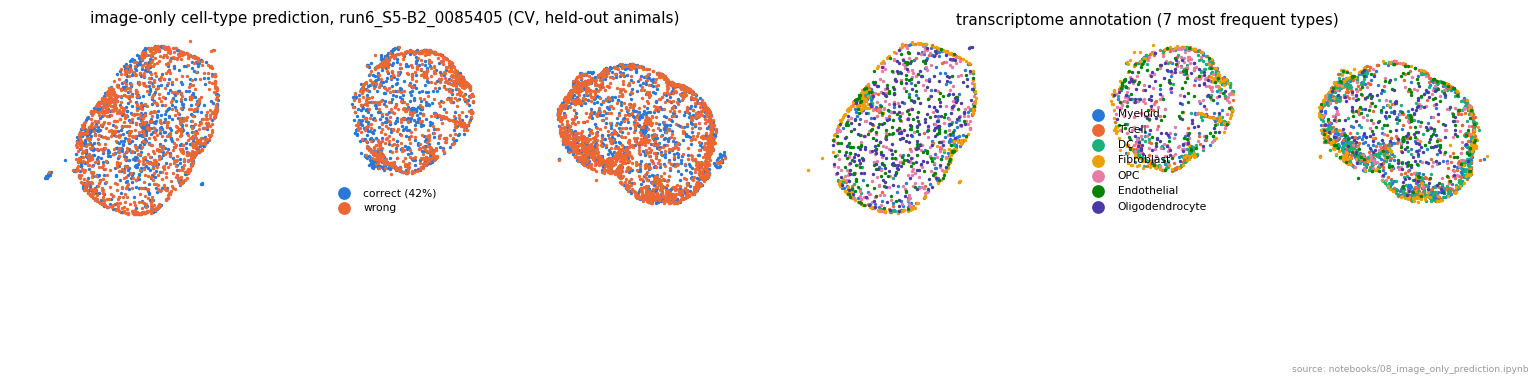

In [6]:
SEC = ct.section_id.value_counts().index[0]
full = cv_predict(ct, ct.Anno_L1_curated, CELL + NBH, "L1_cell+nbhd")  # subsample → plot cells that were predicted
d = ct.loc[ct.index.intersection(full.index)]
d = d[d.section_id == SEC].join(full)
ok = d.true == d.pred
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].scatter(d.x_centroid[ok], -d.y_centroid[ok], s=1.5, color=plotting.CATEGORICAL[0], label=f"correct ({ok.mean():.0%})", rasterized=True)
axs[0].scatter(d.x_centroid[~ok], -d.y_centroid[~ok], s=1.5, color=plotting.CATEGORICAL[1], label="wrong", rasterized=True)
axs[0].set_title(f"image-only cell-type prediction, {SEC} (CV, held-out animals)"); axs[0].legend(markerscale=6, fontsize=7)
top = d.true.value_counts().index[:7]
for k, t_ in enumerate(top):
    m = d.true == t_
    axs[1].scatter(d.x_centroid[m], -d.y_centroid[m], s=1.5, color=plotting.CATEGORICAL[k], label=t_, rasterized=True)
axs[1].set_title("transcriptome annotation (7 most frequent types)"); axs[1].legend(markerscale=6, fontsize=7)
for a in axs:
    a.set_aspect("equal"); a.axis("off")
fig.tight_layout()
plotting.save_fig(fig, "L1_map_correct_wrong", OUT, SRC)

## 3. Subtypes within a type (L2), from images only

In [7]:
rows, sub_res = [], {}
for parent in ["Myeloid", "Astrocyte", "Oligodendrocyte", "Neuron", "Fibroblast", "T cell", "DC"]:
    d = fa[fa.Anno_L1_curated == parent]
    vc2 = d.Anno_L2.value_counts()
    keep = [c for c in vc2.index if vc2[c] >= 300 and "LowQuality" not in c and c not in ("Doublet", "ARTIFACT", "Mixed")]
    if len(keep) < 2:
        continue
    d = d[d.Anno_L2.isin(keep)]
    r = cv_predict(d, d.Anno_L2, CELL + NBH, f"L2_{parent.replace(' ', '_').replace('/', '-')}", max_per_class=5000)
    sub_res[parent] = r
    s = scores(r)
    per = pd.Series(np.diag(confusion_matrix(r.true, r.pred, labels=keep, normalize="true")), index=keep)
    rows.append(dict(parent=parent, subtypes=", ".join(f"{k} ({v:.2f})" for k, v in per.items()), **s))
l2 = pd.DataFrame(rows).set_index("parent")
l2.to_csv(OUT / "L2_within_type.csv")
l2[["balanced acc.", "chance (balanced)", "macro F1", "n", "subtypes"]].round(3)

,balanced acc.,chance (balanced),macro F1,n,subtypes
parent,,,,,
Myeloid,0.533,0.250,0.525,15911.0,"Microglia (0.72), MDM (0.53), CAM (0.61), Myel..."
Astrocyte,0.598,0.250,0.565,12761.0,"Reactive_AST (0.68), Homo_AST (0.60), Neurovas..."
Oligodendrocyte,0.468,0.250,0.467,16438.0,"MOL (0.65), DAO (0.48), NFOL (0.56), OPC/COP (..."
Neuron,0.640,0.333,0.637,12169.0,"Exc (0.57), Inh (0.63), Chol (0.72)"
Fibroblast,0.371,0.125,0.356,24271.0,"Fibroblast (0.25), Meningeal FBs (0.56), EAE -..."
T cell,0.447,0.333,0.419,6344.0,"CD4+ T Cell (0.74), CD8+ T Cell (0.54), T Cell..."
DC,0.661,0.500,0.644,5772.0,"GMP-DC (0.87), CLP-DC (0.45)"


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L2_within_type.png')

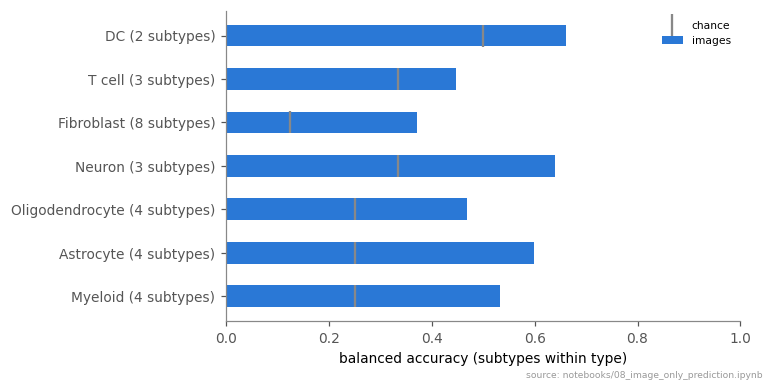

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
y = np.arange(len(l2))
ax.barh(y, l2["balanced acc."], color=plotting.CATEGORICAL[0], height=0.5, label="images")
ax.scatter(l2["chance (balanced)"], y, color="#888888", marker="|", s=200, label="chance", zorder=3)
ax.set_yticks(y, [f"{p} ({len(s.split(','))} subtypes)" for p, s in zip(l2.index, l2.subtypes)])
ax.set_xlabel("balanced accuracy (subtypes within type)"); ax.set_xlim(0, 1); ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "L2_within_type", OUT, SRC)

Microglia vs monocyte-derived macrophages is the immunologically most relevant split — confusion:

In [9]:
if "Myeloid" in sub_res:
    r = sub_res["Myeloid"]
    labs = sorted(r.true.unique())
    print(pd.DataFrame(confusion_matrix(r.true, r.pred, labels=labs, normalize="true"), index=labs, columns=labs).round(2))

            CAM   MDM  Microglia  Myeloid
CAM        0.61  0.17       0.13     0.09
MDM        0.26  0.53       0.15     0.06
Microglia  0.13  0.08       0.72     0.07
Myeloid    0.35  0.17       0.20     0.27


## 4. Anatomy and lesion state from images
Same model on all cell types together. Baseline: the *transcriptome-defined* cell-type composition of the 15 nearest
cells (what the niche annotation itself is built from).

In [10]:
comp = pd.get_dummies(fa.Anno_L1_curated.astype(str)).astype(np.float32)
compn = np.zeros(comp.shape, np.float32)
cv_ = comp.values
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K + 1, len(idx)))
    compn[idx] = cv_[idx][nn[:, 1:]].mean(1)
COMP = [f"comp_{c}" for c in comp.columns]
fa[COMP] = compn
TASKS = {"anatomical region": "Global_anatomical_region", "lesion state": "Curated_niche_state"}
rows, maps = [], {}
for name, col in TASKS.items():
    vc3 = fa[col].value_counts()
    keep = [c for c in vc3.index if vc3[c] >= 2000]
    d = fa[fa[col].isin(keep)]
    for fs_name, feats in (("images (cell + neighbourhood)", CELL + NBH), ("transcriptome cell-type composition", COMP),
                           ("both", CELL + NBH + COMP)):
        r = cv_predict(d, d[col], feats, f"{col}_{fs_name.split()[0]}", max_per_class=8000)
        rows.append(dict(task=name, inputs=fs_name, classes=len(keep), **scores(r)))
        maps[(name, fs_name)] = r
nt = pd.DataFrame(rows)
nt.to_csv(OUT / "anatomy_lesion_prediction.csv", index=False)
nt.round(3)

/tmp/ipykernel_23452/1825654878.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[COMP] = compn
/tmp/ipykernel_23452/1825654878.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[COMP] = compn
/tmp/ipykernel_23452/1825654878.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[COMP] = comp

,task,inputs,classes,balanced acc.,macro F1,chance (balanced),n
0,anatomical region,images (cell + neighbourhood),10,0.625,0.624,0.100,76562.0
1,anatomical region,transcriptome cell-type composition,10,0.683,0.679,0.100,76562.0
2,anatomical region,both,10,0.730,0.729,0.100,76562.0
3,lesion state,images (cell + neighbourhood),7,0.535,0.533,0.143,43759.0
4,lesion state,transcriptome cell-type composition,7,0.648,0.617,0.143,43759.0
5,lesion state,both,7,0.665,0.659,0.143,43759.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/anatomy_lesion_prediction.png')

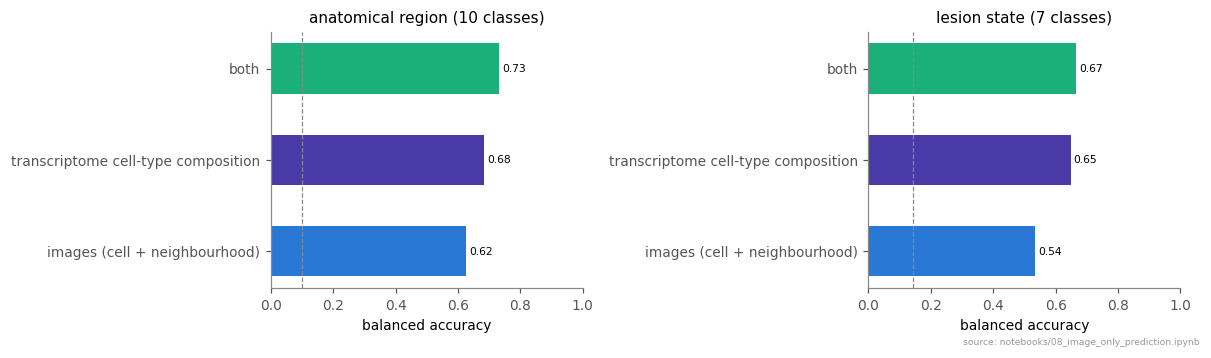

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
for ax, (name, g) in zip(axs, nt.groupby("task", sort=False)):
    ax.barh(g.inputs, g["balanced acc."], color=[plotting.CATEGORICAL[k] for k in (0, 6, 2)], height=0.55)
    ax.axvline(g["chance (balanced)"].iloc[0], color="#888888", lw=0.8, ls="--")
    for i, v in enumerate(g["balanced acc."]):
        ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
    ax.set_title(f"{name} ({g.classes.iloc[0]} classes)"); ax.set_xlim(0, 1)
axs[0].set_xlabel("balanced accuracy"); axs[1].set_xlabel("balanced accuracy")
fig.tight_layout()
plotting.save_fig(fig, "anatomy_lesion_prediction", OUT, SRC)

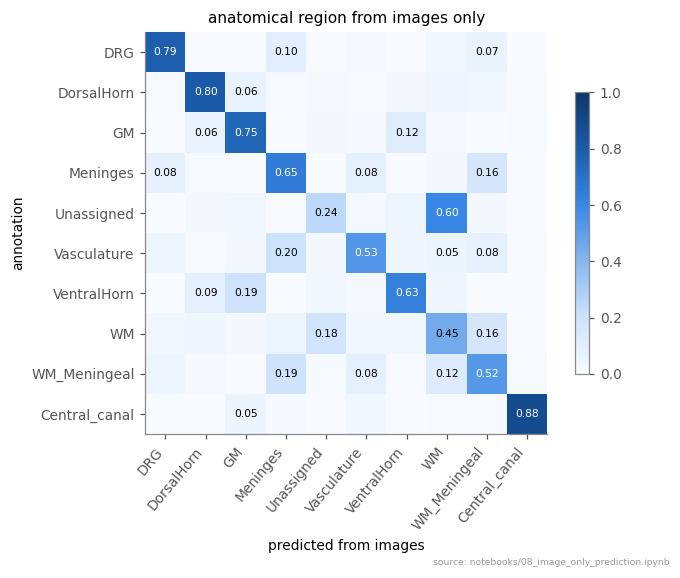

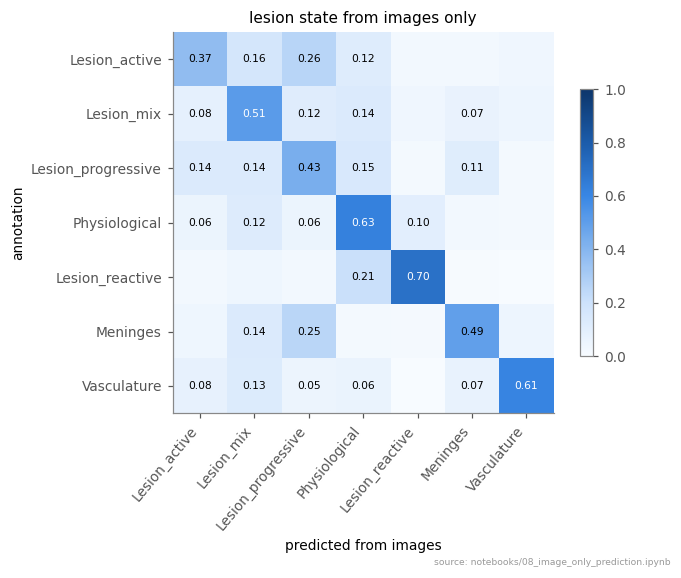

In [12]:
for name in TASKS:
    r = maps[(name, "images (cell + neighbourhood)")]
    labs = list(r.true.value_counts().index)
    cm = confusion_matrix(r.true, r.pred, labels=labs, normalize="true")
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    im = ax.imshow(cm, cmap=plotting.SEQ, vmin=0, vmax=1)
    for i in range(len(labs)):
        for j in range(len(labs)):
            if cm[i, j] >= 0.05:
                ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if cm[i, j] > 0.5 else "black")
    ax.set_xticks(range(len(labs)), labs, rotation=50, ha="right"); ax.set_yticks(range(len(labs)), labs)
    ax.set_xlabel("predicted from images"); ax.set_ylabel("annotation")
    ax.set_title(f"{name} from images only")
    fig.colorbar(im, ax=ax, shrink=0.7)
    fig.tight_layout()
    plotting.save_fig(fig, f"confusion_{name.replace(' ', '_')}", OUT, SRC)

## 5. Animal metadata: model, timepoint, score, sex — images vs transcriptome
Per-cell models trained on other animals (5-fold GroupKFold by animal), predictions averaged per held-out animal.
Same pipeline for three inputs: **images** (cell + neighbourhood), **transcriptome** (50 PCs of log-normalised counts),
**both**. Lumbar cells only (all animals have lumbar tissue), ≤ 1,500 random cells per animal.

Design caveats (from the metadata): *model* is constant within every Xenium section, all relapse-remitting animals are
male and only they have cervical tissue → predicting *model* mostly predicts slide/batch. The **run5 vs run6** task
among relapse-remitting animals is a pure technical-batch control. *Day of sacrifice* and *stage* vary within
sections, so those are the fair biological tests.

In [13]:
import anndata as ad
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score

from beyondboundaries import orthogonality as orth

cfg = data.load_config()
adata = ad.read_h5ad(ROOT / cfg["annotation"]["h5ad"])
meta = adata.obs[["day_of_sacrifice", "run_id"]]
lum = fa[fa.region == "L"].join(meta)
cells = np.concatenate([rng.choice(g.index.values, min(len(g), 1500), replace=False)
                        for _, g in lum.groupby("sample_name", observed=True)])
L = lum.loc[cells].copy()
P = PCA(50, svd_solver="covariance_eigh", random_state=0).fit_transform(orth.lognorm(adata[L.index].X))
TX = [f"txPC{i + 1}" for i in range(50)]
L[TX] = P
del adata, P                                       # counts no longer needed; free memory before the long loops
import gc; gc.collect()
INPUTS = {"images": CELL + NBH, "transcriptome": TX, "both": CELL + NBH + TX}
L["phase"] = L.stage.astype(str).map(lambda s: "pre/onset" if s in ("CFA", "NONSYMPTOM", "OS1") else
                                     "peak" if s.startswith("PEAK") else "remission" if s.startswith("REMISSION") else "chronic")
print(len(L), "cells from", L.sample_name.nunique(), "animals")


def animal_cv(d, target, feats, kind, n_folds=5):
    """Cell-level model, grouped by animal; returns per-animal mean prediction (regression) or class probabilities."""
    X = d[feats].values.astype(np.float32)
    y = d[target].values
    g = d.sample_name.astype(str).values
    pred = np.zeros(len(d)) if kind == "reg" else None
    proba = None
    for tr, te in GroupKFold(min(n_folds, len(np.unique(g)))).split(X, groups=g):
        if kind == "reg":
            m = HistGradientBoostingRegressor(max_iter=300, early_stopping=True, random_state=0).fit(X[tr], y[tr])
            pred[te] = m.predict(X[te])
        else:
            m = HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=0,
                                               class_weight="balanced").fit(X[tr], y[tr].astype(str))
            pp = pd.DataFrame(m.predict_proba(X[te]), columns=m.classes_)
            if proba is None:
                proba = pd.DataFrame(0.0, index=range(len(d)), columns=np.sort(np.unique(y.astype(str))))
            proba.iloc[te, :] = pp.reindex(columns=proba.columns, fill_value=0).values
    if kind == "reg":
        return pd.DataFrame({"true": y, "pred": pred, "animal": g}).groupby("animal").mean()
    out = proba.assign(animal=g, true=y.astype(str)).groupby("animal").agg({**{c: "mean" for c in proba.columns}, "true": "first"})
    out["pred"] = out[proba.columns].idxmax(axis=1)
    return out


TASKS5 = [
    ("clinical score (all)", L, "score_sacrifice", "reg"),
    ("day of sacrifice (chronic)", L[L.model == "CHRONIC"], "day_of_sacrifice", "reg"),
    ("day of sacrifice (relapse-remitting)", L[L.model == "RELAPSE REMITTING"], "day_of_sacrifice", "reg"),
    ("phase (chronic: pre/onset · peak · chronic)", L[L.model == "CHRONIC"], "phase", "clf"),
    ("phase (RR: peak · remission)", L[L.model == "RELAPSE REMITTING"], "phase", "clf"),
    ("sex (chronic)", L[L.model == "CHRONIC"], "sex", "clf"),
    ("run5 vs run6 (RR) — batch control", L[L.model == "RELAPSE REMITTING"], "run_id", "clf"),
    ("model: chronic vs RR — confounded with slide/sex/level", L, "model", "clf"),
]
rows, store = [], {}
for name, d, target, kind in TASKS5:
    for inp, feats in INPUTS.items():
        slug = "".join(ch if ch.isalnum() else "_" for ch in name.split(" —")[0]).strip("_")
        while "__" in slug:
            slug = slug.replace("__", "_")
        cache = CACHE / f"animal_{slug}__{inp}.parquet"
        if cache.exists():
            r = pd.read_parquet(cache)
        else:
            r = animal_cv(d, target, feats, kind)
            r.to_parquet(cache)
        store[(name, inp)] = r
        if kind == "reg":
            rho, p = spearmanr(r.true, r.pred)
            rows.append(dict(task=name, input=inp, animals=len(r), metric="Spearman ρ (per animal)", value=rho, p=p))
        else:
            acc = (r.true == r.pred).mean()
            rows.append(dict(task=name, input=inp, animals=len(r), metric="accuracy (per animal)", value=acc,
                             p=np.nan, chance=1 / r.true.nunique()))
res5 = pd.DataFrame(rows)
res5.to_csv(OUT / "animal_metadata_prediction.csv", index=False)
res5.pivot_table(index=["task", "metric"], columns="input", values="value", sort=False).round(2)

37500 cells from 25 animals


,input,images,transcriptome,both
task,metric,,,
clinical score (all),Spearman ρ (per animal),0.62,0.79,0.76
day of sacrifice (chronic),Spearman ρ (per animal),0.52,0.84,0.75
day of sacrifice (relapse-remitting),Spearman ρ (per animal),-0.57,0.03,-0.36
phase (chronic: pre/onset · peak · chronic),accuracy (per animal),0.56,1.00,0.94
phase (RR: peak · remission),accuracy (per animal),0.44,0.78,0.44
sex (chronic),accuracy (per animal),0.25,0.38,0.25
run5 vs run6 (RR) — batch control,accuracy (per animal),1.00,0.44,0.89
model: chronic vs RR — confounded with slide/sex/level,accuracy (per animal),0.72,0.96,0.76


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/animal_metadata_prediction.png')

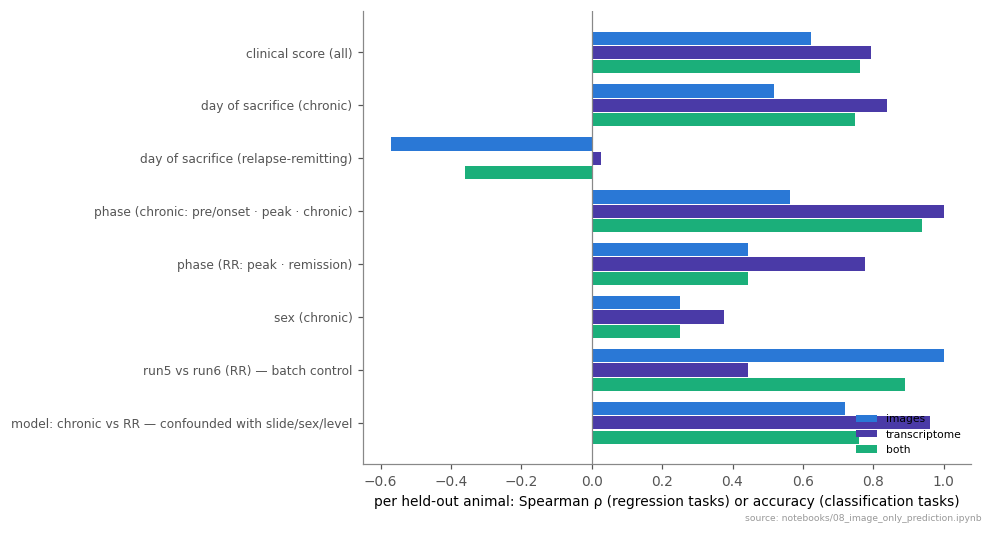

In [14]:
pv = res5.pivot_table(index="task", columns="input", values="value", sort=False)[["images", "transcriptome", "both"]]
fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(pv))
for k, c in enumerate(pv.columns):
    ax.barh(y + (k - 1) * 0.27, pv[c], height=0.25, color=plotting.CATEGORICAL[[0, 6, 2][k]], label=c)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(y, pv.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("per held-out animal: Spearman ρ (regression tasks) or accuracy (classification tasks)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "animal_metadata_prediction", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/animal_metadata_scatter.png')

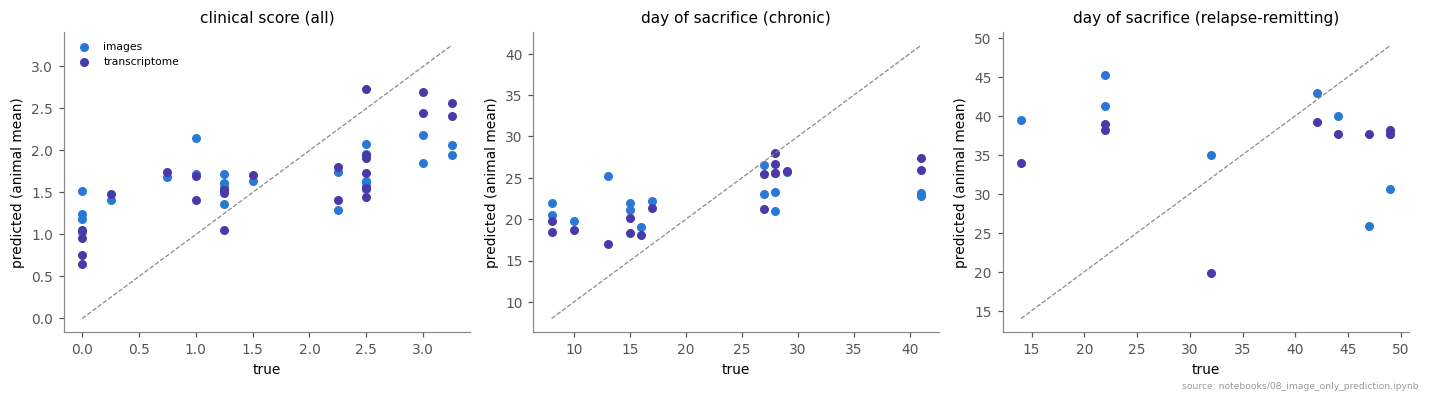

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, name in zip(axs, ["clinical score (all)", "day of sacrifice (chronic)", "day of sacrifice (relapse-remitting)"]):
    for k, inp in enumerate(["images", "transcriptome"]):
        r = store[(name, inp)]
        ax.scatter(r.true, r.pred, s=24, color=plotting.CATEGORICAL[[0, 6][k]], label=inp)
    lo, hi = r.true.min(), r.true.max()
    ax.plot([lo, hi], [lo, hi], color="#888888", lw=0.8, ls="--")
    ax.set(title=name, xlabel="true", ylabel="predicted (animal mean)")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "animal_metadata_scatter", OUT, SRC)

## 6. Lesion maps from images alone
Lesion niche (any `Lesion_*` state) vs physiological niche, per cell. Inputs: image features of the cell, its 15
nearest cells, and a wider 50-cell image neighbourhood (lesions are tissue-scale). Trained by animal (5-fold
GroupKFold; ≤ 20,000 cells per class from the training animals), then **every cell of the held-out animals** is
predicted, so whole sections can be drawn. Baseline: transcriptome cell-type composition of the 15 nearest cells.

In [16]:
K2 = 50
nb50 = np.full((len(fa), len(NB_BASE)), np.nan, np.float32)
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K2 + 1, len(idx)))
    nb50[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)
NBH50 = [f"nbhd50_{c}" for c in NB_BASE]
fa[NBH50] = nb50
les = fa[fa.Curated_niche_state.astype(str).str.startswith("Lesion") | (fa.Curated_niche_state == "Physiological")].copy()
les["y_lesion"] = les.Curated_niche_state.astype(str).str.startswith("Lesion").astype(int)
print(f"{len(les):,} cells; lesion fraction {les.y_lesion.mean():.2f}; {les.sample_name.nunique()} animals")


def lesion_cv(feats, key, per_class=20000):
    cache = CACHE / f"lesionmap_{key}.parquet"
    if cache.exists():
        return pd.read_parquet(cache).p
    p = pd.Series(np.nan, index=les.index)
    g = les.sample_name.astype(str).values
    for tr, te in GroupKFold(5).split(les, groups=g):
        trd = les.iloc[tr]
        sub = np.concatenate([rng.choice(gg.index.values, min(len(gg), per_class), replace=False)
                              for _, gg in trd.groupby("y_lesion")])
        m = HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=0).fit(
            les.loc[sub, feats].values.astype(np.float32), les.loc[sub, "y_lesion"].values)
        p.iloc[te] = m.predict_proba(les.iloc[te][feats].values.astype(np.float32))[:, 1]
    p.to_frame("p").to_parquet(cache)
    return p


LES_INPUTS = {"images (cell + 15 + 50 neighbours)": CELL + NBH + NBH50,
              "images (cell only)": CELL,
              "transcriptome cell-type composition (15 NN)": COMP,
              "both": CELL + NBH + NBH50 + COMP}
lp, rows = {}, []
for name, feats in LES_INPUTS.items():
    p = lesion_cv(feats, name.split(" (")[0].replace(" ", "_") + ("_cellonly" if "cell only" in name else ""))
    lp[name] = p
    per_an = [roc_auc_score(g.y_lesion, p[g.index]) for _, g in les.groupby("sample_name", observed=True)
              if 0 < g.y_lesion.mean() < 1 and min(g.y_lesion.sum(), (1 - g.y_lesion).sum()) >= 50]
    rows.append(dict(inputs=name, AUROC=roc_auc_score(les.y_lesion, p), median_AUROC_per_animal=np.median(per_an),
                     animals=len(per_an)))
lt8 = pd.DataFrame(rows).set_index("inputs")
lt8.to_csv(OUT / "lesion_map_auroc.csv")
lt8.round(3)

/tmp/ipykernel_23452/1906922811.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = nb50
/tmp/ipykernel_23452/1906922811.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = nb50
/tmp/ipykernel_23452/1906922811.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = nb5

473,909 cells; lesion fraction 0.68; 25 animals


,AUROC,median_AUROC_per_animal,animals
inputs,,,
images (cell + 15 + 50 neighbours),0.900,0.898,25
images (cell only),0.838,0.841,25
transcriptome cell-type composition (15 NN),0.921,0.918,25
both,0.934,0.932,25


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/lesion_map_auroc.png')

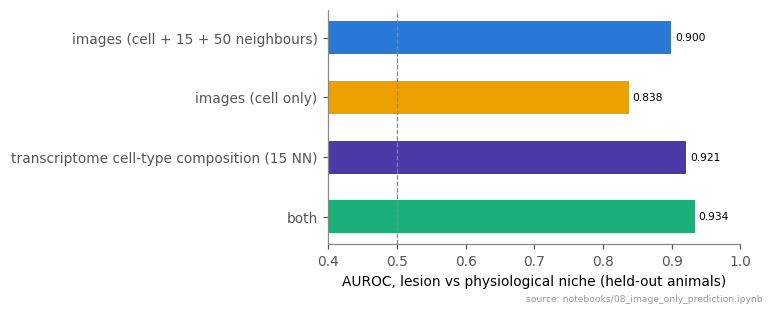

In [17]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(lt8.index, lt8.AUROC, color=[plotting.CATEGORICAL[k] for k in (0, 3, 6, 2)], height=0.55)
for i, v in enumerate(lt8.AUROC):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=7)
ax.axvline(0.5, color="#888888", lw=0.8, ls="--")
ax.set_xlim(0.4, 1); ax.set_xlabel("AUROC, lesion vs physiological niche (held-out animals)"); ax.invert_yaxis()
fig.tight_layout()
plotting.save_fig(fig, "lesion_map_auroc", OUT, SRC)

### Maps: transcriptome-defined lesions vs lesion probability from images alone
Three sections with mixed lesion/physiological tissue; image probability smoothed over each cell's 15 nearest cells
for display. Every cell shown was in a held-out fold (its animal was not used to train the model that scored it).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/lesion_maps_images_vs_annotation.png')

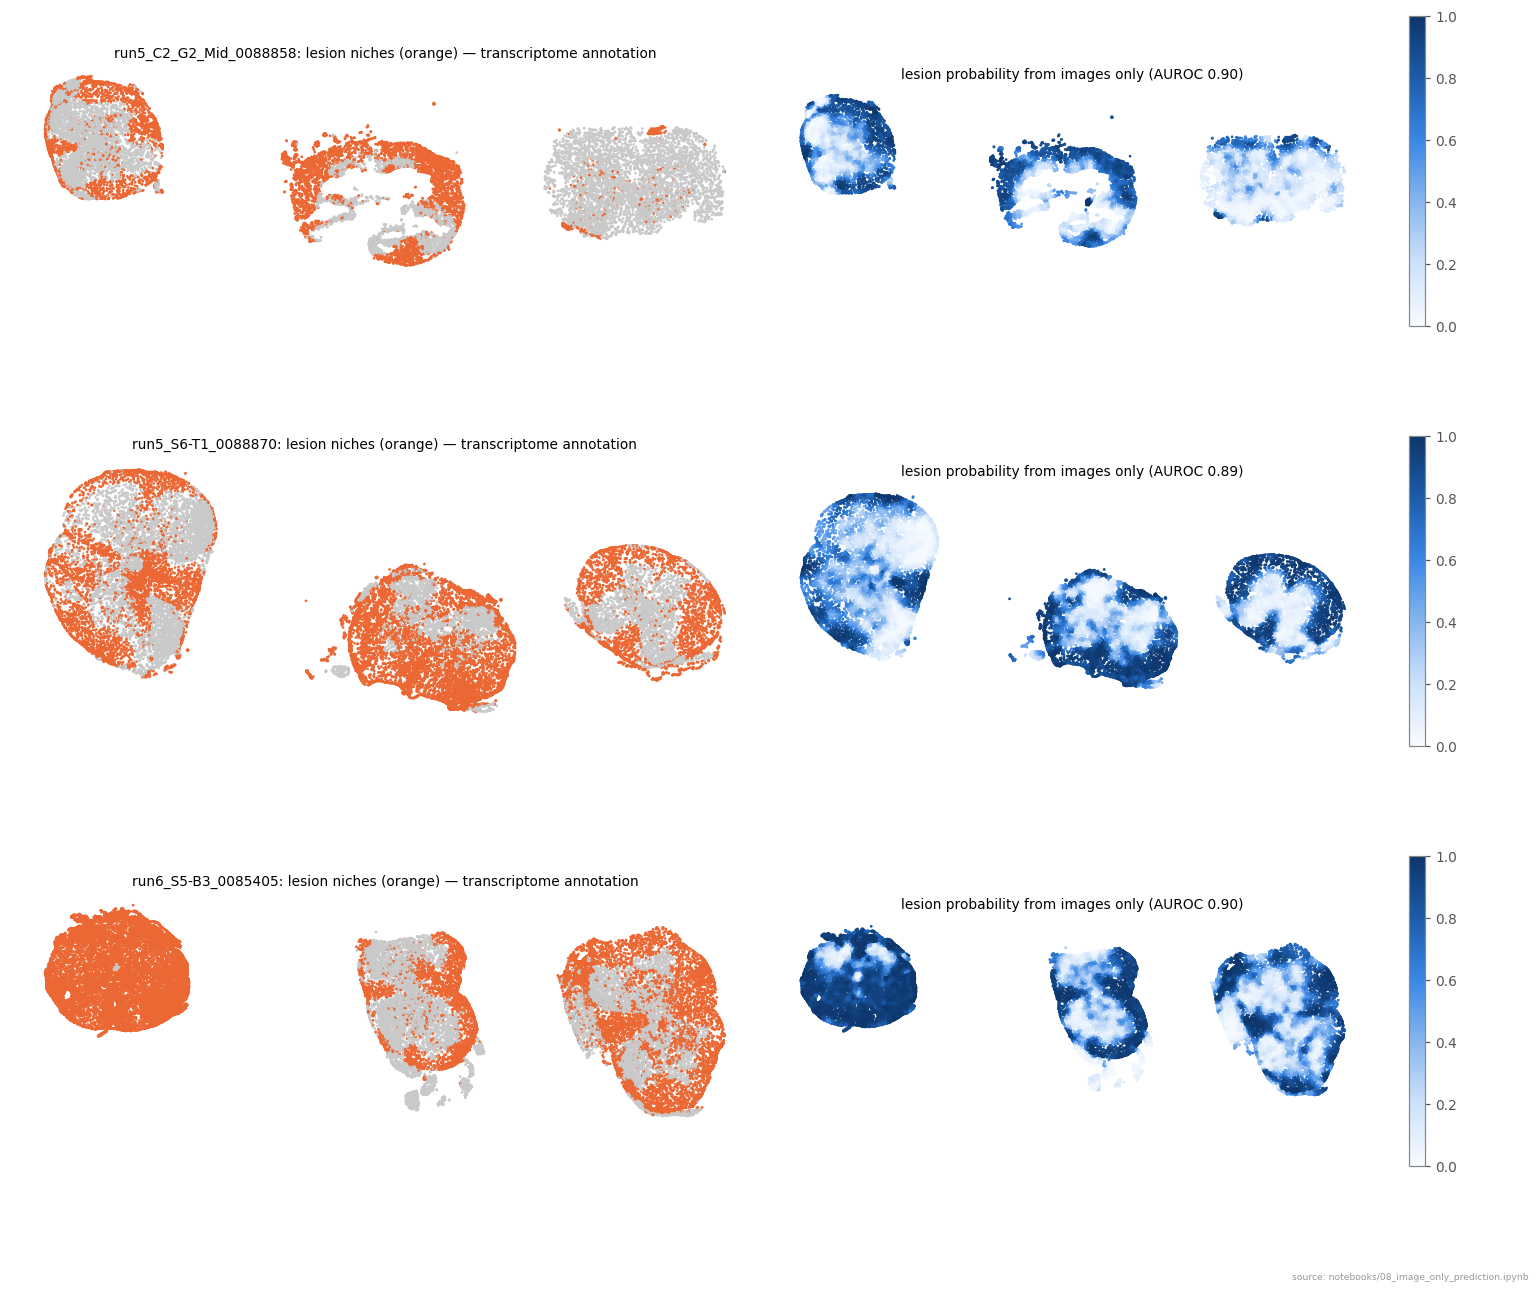

In [18]:
p_img = lp["images (cell + 15 + 50 neighbours)"]
mix = les.groupby("section_id", observed=True).y_lesion.mean()
SECS = mix[(mix > 0.25) & (mix < 0.75)].sort_values().index[[0, len(mix[(mix > 0.25) & (mix < 0.75)]) // 2, -1]]
fig, axs = plt.subplots(len(SECS), 2, figsize=(14, 4.2 * len(SECS)))
for r_, sec in enumerate(SECS):
    d = les[les.section_id == sec]
    xy = d[["x_centroid", "y_centroid"]].values
    _, nn = cKDTree(xy).query(xy, k=16)
    ps = p_img[d.index].values[nn].mean(1)
    auc = roc_auc_score(d.y_lesion, p_img[d.index])
    axs[r_, 0].scatter(d.x_centroid, -d.y_centroid, s=0.6, c=np.where(d.y_lesion, plotting.CATEGORICAL[1], "#c9c9c9"),
                       rasterized=True)
    axs[r_, 0].set_title(f"{sec}: lesion niches (orange) — transcriptome annotation", fontsize=9)
    sc_ = axs[r_, 1].scatter(d.x_centroid, -d.y_centroid, s=0.6, c=ps, cmap=plotting.SEQ, vmin=0, vmax=1, rasterized=True)
    axs[r_, 1].set_title(f"lesion probability from images only (AUROC {auc:.2f})", fontsize=9)
    fig.colorbar(sc_, ax=axs[r_, 1], shrink=0.6)
    for a in axs[r_]:
        a.set_aspect("equal"); a.axis("off")
fig.tight_layout()
plotting.save_fig(fig, "lesion_maps_images_vs_annotation", OUT, SRC)

Which image features drive lesion calls? Univariate AUROC of each feature (lesion vs physiological), top 20 — note
neighbourhood features (`nbhd*`) summarise tissue around the cell.

,AUROC
nbhd50_smavim_glcm_correlation,0.777
nbhd_smavim_glcm_correlation,0.764
nbhd50_smavim_cyto_mean,0.763
nbhd_smavim_cyto_mean,0.751
smavim_glcm_entropy,0.737
smavim_glcm_asm,0.265
smavim_glcm_homogeneity,0.281
smavim_cyto_p90,0.713
nbhd50_smavim_terr_mean,0.713
smavim_rim_p90,0.712


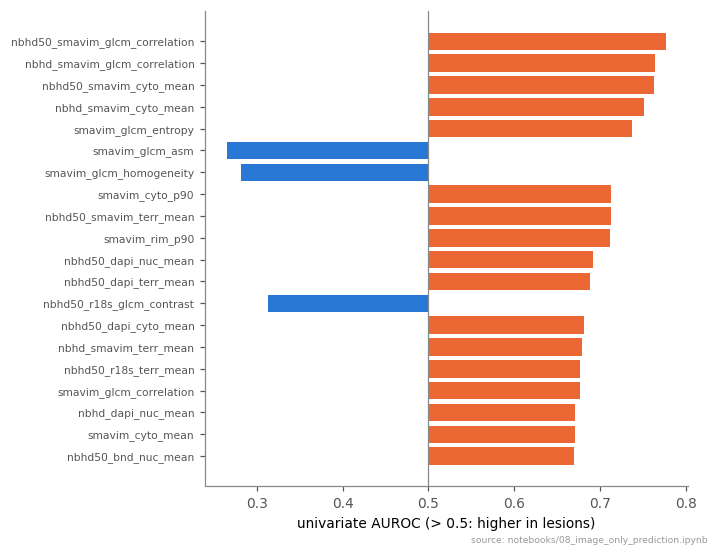

In [19]:
fe = pd.Series({c: roc_auc_score(les.y_lesion, les[c].fillna(les[c].median())) for c in CELL + NBH + NBH50})
fe = (fe - 0.5).abs().sort_values(ascending=False).head(20).index
fe_t = pd.DataFrame({"AUROC": [roc_auc_score(les.y_lesion, les[c].fillna(les[c].median())) for c in fe]}, index=fe)
fe_t.to_csv(OUT / "lesion_top_image_features.csv")
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(fe_t.index, fe_t.AUROC - 0.5, left=0.5, color=[plotting.CATEGORICAL[1] if v > 0.5 else plotting.CATEGORICAL[0] for v in fe_t.AUROC])
ax.axvline(0.5, color="#888888", lw=0.8); ax.invert_yaxis()
ax.set_xlabel("univariate AUROC (> 0.5: higher in lesions)"); ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
plotting.save_fig(fig, "lesion_top_image_features", OUT, SRC)
fe_t.round(3)